# White wine EDA

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import pandas as pd
import numpy as np
# import os

In [5]:
zip_path = "wine+quality.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
	zip_ref.printdir()

File Name                                             Modified             Size
winequality-red.csv                            2023-05-22 22:24:00        84199
winequality-white.csv                          2023-05-22 22:24:00       264426
winequality.names                              2023-05-22 22:24:00         3305


In [6]:
with zipfile.ZipFile(zip_path) as z:
    with z.open('winequality-white.csv') as f:
        white_wine = pd.read_csv(f,sep = ";")

In [7]:
white_wine.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [8]:
white_wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [9]:
white_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [10]:
num_features = white_wine.select_dtypes(include=['float64', 'int64']).columns
white_wine[num_features].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [11]:
white_wine['quality'].unique()

array([6, 5, 7, 8, 4, 3, 9])

In [12]:
def map_quality_category(x):
    if x <= 4:
        return 'Low'
    elif x <= 6:
        return 'Medium'
    else:
        return 'High'

# lets apply our function
white_wine['quality_label'] = white_wine['quality'].apply(map_quality_category)

In [13]:
white_wine.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,Medium
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,Medium
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,Medium
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,High
4897,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,Medium


In [26]:
df = white_wine.copy()

In [27]:
df.drop(columns=['quality_label'], inplace=True)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB

In [65]:
df.head(4)
# df['quality'].unique()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [91]:

from sklearn.ensemble import RandomForestClassifier


label = df['quality']
features = df.drop(columns=['quality'])

# data into training and testing sets
features_train, features_test, label_train, label_test = train_test_split(features, label, test_size=0.2, random_state=42)

# split the data
clf = RandomForestClassifier(n_estimators=100, random_state=234)

clf.fit(features_train, label_train)
pred = clf.predict(features_test)
print(pred)


[7 8 7 5 7 6 5 5 6 5 7 5 7 5 6 5 6 6 7 6 5 6 5 6 6 5 5 6 7 5 5 5 6 6 5 7 6
 5 5 6 5 6 6 6 5 6 6 5 5 5 5 5 6 6 6 6 6 6 6 7 6 6 6 7 6 7 6 5 6 6 5 6 5 5
 6 6 6 6 7 7 6 6 6 6 6 6 5 7 5 6 7 5 6 6 6 6 6 6 5 6 5 6 7 6 6 6 7 7 6 6 6
 7 6 5 5 7 7 6 5 8 6 7 6 6 7 6 7 6 7 5 6 6 6 6 5 6 6 6 6 5 6 6 6 6 6 5 5 5
 5 5 6 6 6 6 7 5 6 6 6 6 6 5 6 6 7 6 5 6 5 6 5 6 6 5 7 6 6 6 6 5 7 6 6 6 5
 6 6 5 6 5 6 6 7 6 6 5 7 7 5 6 7 5 6 6 5 6 7 7 6 7 6 6 6 7 5 5 6 5 6 6 5 5
 6 6 6 5 6 6 6 5 6 5 6 6 5 7 6 6 6 7 5 4 7 6 7 5 5 5 6 6 6 4 6 5 6 5 6 5 6
 6 6 5 5 5 7 6 6 6 7 5 5 6 6 7 6 6 5 5 7 5 6 6 6 5 6 7 8 5 6 6 6 6 6 5 8 5
 5 6 6 5 5 5 6 5 7 5 5 6 6 6 6 6 6 6 7 7 6 6 5 7 7 7 6 6 5 5 7 5 8 5 6 6 6
 6 5 6 7 6 8 5 6 6 5 6 5 5 6 4 7 6 7 7 6 6 6 5 6 7 7 5 5 5 6 5 5 5 5 5 5 6
 6 6 6 6 6 6 6 5 7 5 6 6 5 6 6 6 7 6 5 5 5 6 6 6 5 6 5 6 6 5 6 6 6 6 6 7 6
 5 7 7 5 6 8 6 6 6 5 6 5 6 7 6 6 7 7 6 5 6 6 6 7 6 7 5 6 5 8 6 5 6 6 7 6 5
 5 6 7 6 5 6 5 5 7 6 7 6 5 6 5 5 6 6 6 6 6 7 6 6 6 5 5 6 6 5 5 6 5 6 6 6 7
 5 6 5 5 6 6 5 5 6 6 5 6 

In [94]:
print(accuracy_score(pred, label_test))
# label_train.head(4)

0.7112244897959183


In [96]:
y = df['quality']
X = df.drop(columns=['quality'])

# lets use logistic regression algorithm to train our base model

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=234)

model = RandomForestClassifier(n_estimators=100, random_state=234)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.70      0.72      0.71       291
           6       0.68      0.78      0.73       440
           7       0.70      0.57      0.63       176
           8       0.88      0.43      0.58        35
           9       0.00      0.00      0.00         1

    accuracy                           0.69       980
   macro avg       0.51      0.38      0.42       980
weighted avg       0.69      0.69      0.68       980



/Users/seyistry/Documents/venus/ai-engineer/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/seyistry/Documents/venus/ai-engineer/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/seyistry/Documents/venus/ai-engineer/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

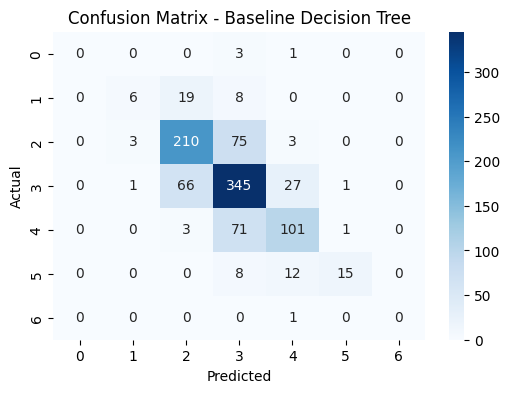

In [ ]:


y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix 
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()